In [121]:
import pickle as pkl
import cv2 as cv
import numpy as np
import seaborn as sns
from matplotlib import cm
import matplotlib.pyplot as plt
import os
import sys

In [122]:
def heatmap_on_image(heatmap, image):
    plt.figure(figsize=(108,36),dpi=1)
    hmax = sns.heatmap(heatmap, vmin=-1, vmax=1,
                    cmap="bwr",
                    xticklabels=False, yticklabels=False, cbar=False, 
                    alpha=1, zorder=1)
    # plt.savefig("os.path.join(relevance_maps_path, "heatmap.png"))
    hmax.imshow(image,
                cmap="gray",
                alpha=0.5,
                aspect = hmax.get_aspect(),
                extent = hmax.get_xlim() + hmax.get_ylim(),
                zorder = 2)
    plt.tight_layout()
    # plt.savefig("os.path.join(relevance_maps_path, "heatmap_background.png"))

    ax = plt.gca()
    canvas = ax.figure.canvas
    canvas.draw()
    hoi = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
    hoi = np.reshape(hoi, (36,108,3))
    hoi = cv.cvtColor(hoi,cv.COLOR_BGR2RGBA)
    return hoi


In [123]:
relevance_maps_path = "2D heatmaps"

In [124]:
mask_path = "pubis_data_proc_25_panorama_seleccion_javi_gray_mask"

In [125]:
gray_path = "pubis_data_proc_25_panorama_seleccion_javi_gray_mask"

In [126]:
sample = "367"
# red = "panorama(Y)"
red = "resnet(X,Y,Z)"
# axis = "Z"
side = "Izq"

(108, 36)
0.0 0.46908212
(36, 108)
float32
0.0 0.46908212
(36, 72)
(36, 72)
(36, 108)
(36, 108, 4)
(108, 36)
0.0 0.23636198
(36, 108)
float32
0.0 0.23636198
(36, 72)
(36, 72)
(36, 108)
(36, 108, 4)
(108, 36)
0.0 0.55582553
(36, 108)
float32
0.0 0.55582553
(36, 72)
(36, 72)
(36, 108)
(36, 108, 4)


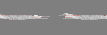

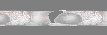

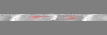

In [127]:
for axis in ["X", "Y", "Z"]:
    save_folder = os.path.join(relevance_maps_path, red,  sample)
    os.makedirs(save_folder, exist_ok=True)
    file = os.path.join(relevance_maps_path,red,sample,"{}_{}_{}_2channels".format(sample, side, axis))
    with open(file+'.pkl', 'rb') as f:
        data = pkl.load(f)

    data.shape

    img = np.array(data).T
    cv.imshow("img_read", img)
    print(img.shape)

    # img = np.where(img > 0.01, 1.0, img)
    img = cv.resize(img, (108, 36))
    print(np.min(img), np.max(img))

    cv.imshow("img", img)
    print(img.shape)

    mask = cv.imread(os.path.join(mask_path, "{}_{}".format(sample,side), "{}_{}_0_panorama_ext_{}_gray_mask_input.png".format(sample,side,axis)), cv.IMREAD_GRAYSCALE)
    cv.imshow("mask", mask)

    mask = mask / 255.0
    # img = img * mask
    img = img.astype('float32')
    print(img.dtype)
    print(np.min(img), np.max(img))

    cv.imshow("Final img", img)
    # cv.imwrite('relevance_map.png', cv.resize(img, (540, 180))*255)
    cv.imwrite("relevance_{}_{}_{}.png".format(sample,side,axis), cv.resize(img, (0, 0), fx = 5, fy = 5)*255)

    img_izq = img[:,:72]
    print(img_izq.shape)
    cv.imwrite("relevance_map_{}_{}_{}_izq.png".format(sample,side,axis), img_izq*255)
    cv.imshow("Final izq", img_izq)

    img_dch = img[:,36:]
    print(img_dch.shape)
    cv.imwrite("relevance_map_{}_{}_{}_dch.png".format(sample,side,axis), img_dch*255)
    cv.imshow("Final dch", img_dch)

    panorama = cv.imread(os.path.join(mask_path, "{}_{}".format(sample,side), "{}_{}_0_panorama_ext_{}_gray_input.png".format(sample,side,axis)), cv.IMREAD_GRAYSCALE)
    print(panorama.shape)
    heatmap = heatmap_on_image(img, panorama)
    print(heatmap.shape)
    heatmap = cv.resize(heatmap, (5400, 1800))
    # heatmap = cv.resize(heatmap, (0, 0), fx = 5, fy = 5)
    cv.imshow("Heatmap img", heatmap)
    cv.imwrite("heatmap_{}_{}_{}.png".format(sample,side,axis), heatmap)


In [128]:
cv.waitKey(0)
cv.destroyAllWindows()